In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(torch.cuda.is_available())

False


In [2]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(path)
print(os.listdir(path))

C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
['seg_pred', 'seg_test', 'seg_train']


In [3]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir  = os.path.join(path, "seg_test", "seg_test")
pred_dir  = os.path.join(path, "seg_pred", "seg_pred")

for d in [train_dir, test_dir]:
    print(d)
    for cls in sorted(os.listdir(d)):
        print("  ", cls, len(os.listdir(os.path.join(d, cls))))

C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
   buildings 2191
   forest 2271
   glacier 2404
   mountain 2512
   sea 2274
   street 2382
C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test
   buildings 437
   forest 474
   glacier 553
   mountain 525
   sea 510
   street 501


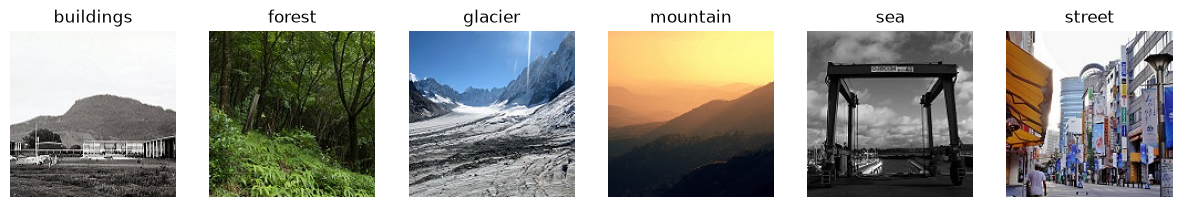

In [4]:
from PIL import Image

classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

plt.figure(figsize=(15, 3))
position = 1

for name in classes:
    
    folder = train_dir + "/" + name

    files = os.listdir(folder)

    image = Image.open(folder + "/" + files[0])

    plt.subplot(1, 6, position)

    plt.imshow(image)
    plt.title(name)
    plt.axis("off")

    position = position + 1
plt.show()

In [5]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

print(len(train_data))
print(len(test_data))
print(train_data.class_to_idx)

14034
3000
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [6]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

generator = torch.Generator().manual_seed(42)

train_part, val_part = random_split(train_data, [train_size, val_size], generator=generator)

print("train:", len(train_part))
print("validation:", len(val_part))
print("test:", len(test_data))

train: 11227
validation: 2807
test: 3000


### DataLoader

In [8]:
batch_size = 32

train_loader = DataLoader(train_part, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_part, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("train batch :", len(train_loader))
print("validation batch :", len(val_loader))
print("test batch :", len(test_loader))

train batch : 351
validation batch : 88
test batch : 94


torch.Size([32, 3, 150, 150])
tensor([4, 5, 3, 0, 3, 2, 3, 1, 5, 0])


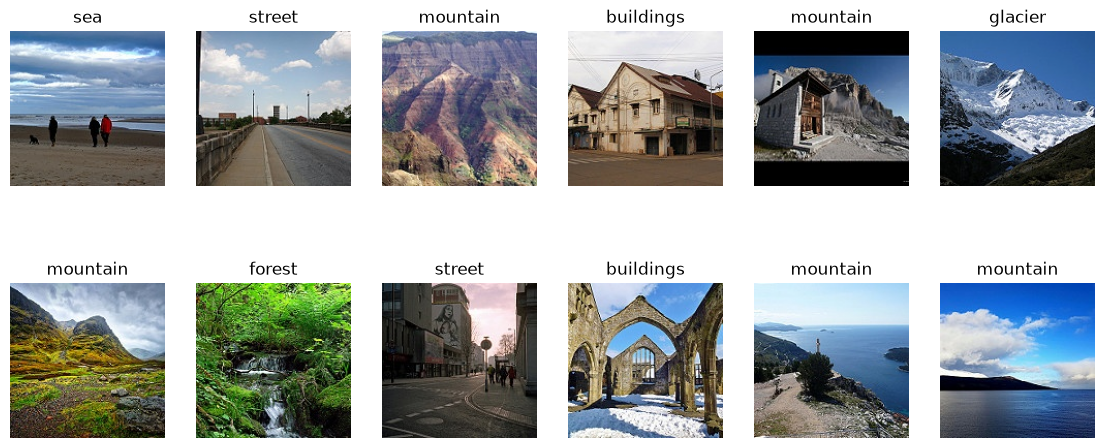

In [9]:
# loader take first Batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

class_names = train_data.classes

plt.figure(figsize=(14, 6))

for i in range(12):
    image = images[i]

    # Undo Normalize 
    image = image * 0.5 + 0.5

    # matplotlib asks that
    image = image.permute(1, 2, 0)

    plt.subplot(2, 6, i + 1)
    plt.imshow(image)

    # number to label ex 1-> 'forest'
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()